# Amostragem Estratificada — Gold Set SIREVA-SUS

Seleciona ~180 sentenças do silver para revisão manual (gold standard).

**Estratégia:**
- Estratificação por relatório (2013–2024) proporcional ao tamanho
- 70% das sentenças **com** entidades silver (maximiza valor da revisão)
- 30% das sentenças **sem** entidades (necessário para calcular precisão corretamente)
- Filtro de qualidade: exclui sentenças muito curtas (títulos, cabeçalhos)

**Input:** `data/silver/*.jsonl`  
**Output:** `data/gold/gold_sample.jsonl` + `data/gold/label_studio.json`

## 1. Setup

In [1]:
import json
import random
import math
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

random.seed(42)  # reprodutibilidade

PROJECT_ROOT  = Path(".").resolve()
DATA_SILVER   = PROJECT_ROOT / "data" / "silver"
DATA_GOLD     = PROJECT_ROOT / "data" / "gold"
DATA_GOLD.mkdir(parents=True, exist_ok=True)

def read_jsonl(path):
    with path.open(encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]

print("Setup OK")

Setup OK


## 2. Explorar dados silver

In [2]:
silver_files = sorted(DATA_SILVER.glob("*.jsonl"))

rows = []
all_silver = []
for sf in silver_files:
    recs = read_jsonl(sf)
    all_silver.extend(recs)
    with_ent  = [r for r in recs if any(t != "O" for t in r["bio_tags"])]
    no_ent    = [r for r in recs if all(t == "O" for t in r["bio_tags"])]
    lens      = [len(r["tokens"]) for r in recs]
    rows.append({
        "relatorio":     sf.stem,
        "total":         len(recs),
        "com_entidade":  len(with_ent),
        "sem_entidade":  len(no_ent),
        "pct_com_ent":   round(len(with_ent) / len(recs) * 100, 1),
        "tokens_med":    round(sum(lens) / len(lens), 1),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nTotal: {df['total'].sum()} sentenças | {df['com_entidade'].sum()} com entidade")

  relatorio  total  com_entidade  sem_entidade  pct_com_ent  tokens_med
sireva_2013    257            57           200         22.2         5.5
sireva_2014    249            52           197         20.9         5.6
sireva_2015    255            53           202         20.8         5.7
sireva_2016    266            61           205         22.9         5.7
sireva_2017    230            52           178         22.6         5.7
sireva_2018    238            48           190         20.2         5.8
sireva_2019    243            55           188         22.6         6.3
sireva_2020    274            69           205         25.2         6.1
sireva_2021    281            66           215         23.5         6.0
sireva_2022    295            67           228         22.7         5.9
sireva_2023    385           107           278         27.8         6.1
sireva_2024    370            85           285         23.0         6.3

Total: 3343 sentenças | 772 com entidade


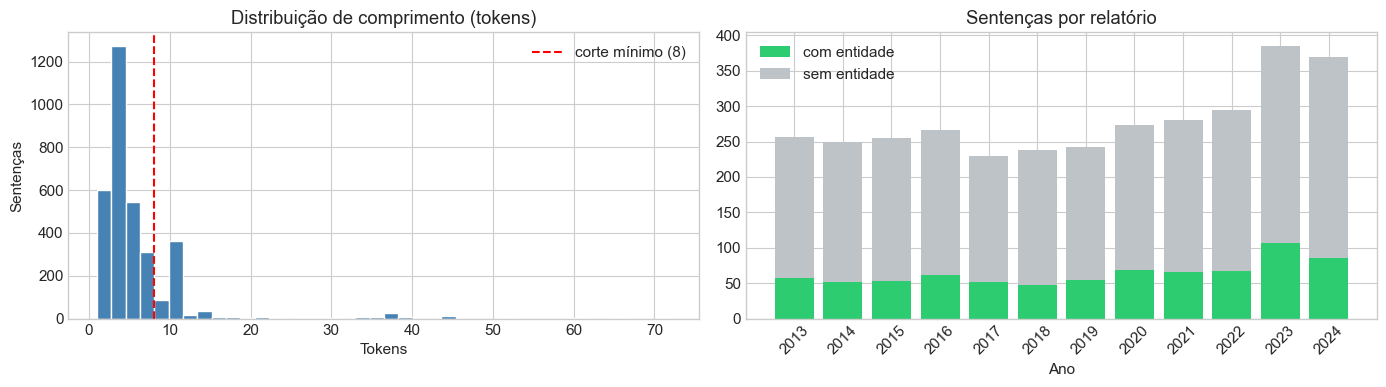

Sentenças com < 8 tokens (a excluir): 2564 (76.7%)


In [3]:
# Distribuição de comprimento (em tokens)
lens_all = [len(r["tokens"]) for r in all_silver]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lens_all, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição de comprimento (tokens)")
axes[0].set_xlabel("Tokens")
axes[0].set_ylabel("Sentenças")
axes[0].axvline(8, color="red", linestyle="--", label="corte mínimo (8)")
axes[0].legend()

anos = [r.replace("sireva_", "") for r in df["relatorio"]]
axes[1].bar(anos, df["com_entidade"], label="com entidade", color="#2ecc71")
axes[1].bar(anos, df["sem_entidade"], bottom=df["com_entidade"], label="sem entidade", color="#bdc3c7")
axes[1].set_title("Sentenças por relatório")
axes[1].set_xlabel("Ano")
axes[1].legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

short = sum(1 for l in lens_all if l < 8)
print(f"Sentenças com < 8 tokens (a excluir): {short} ({short/len(lens_all)*100:.1f}%)")

## 3. Parâmetros de amostragem

Ajuste aqui antes de rodar.

In [4]:
N_TARGET      = 180    # total de sentenças no gold set
PCT_COM_ENT   = 0.70   # fração com entidade (0.70 = 70%)
MIN_TOKENS    = 8      # exclui sentenças com menos tokens (títulos, cabeçalhos)
MAX_TOKENS    = 60     # exclui sentenças muito longas (tabelas concatenadas)

N_COM = round(N_TARGET * PCT_COM_ENT)    # sentenças com entidade
N_SEM = N_TARGET - N_COM                 # sentenças sem entidade

print(f"Target total:         {N_TARGET}")
print(f"Com entidade:         {N_COM} ({PCT_COM_ENT*100:.0f}%)")
print(f"Sem entidade:         {N_SEM} ({(1-PCT_COM_ENT)*100:.0f}%)")
print(f"Filtro comprimento:   [{MIN_TOKENS}, {MAX_TOKENS}] tokens")

Target total:         180
Com entidade:         126 (70%)
Sem entidade:         54 (30%)
Filtro comprimento:   [8, 60] tokens


## 4. Filtrar candidatas

In [5]:
def is_valid(sent):
    """Filtra sentenças de baixa qualidade."""
    n = len(sent["tokens"])
    if n < MIN_TOKENS or n > MAX_TOKENS:
        return False
    text = sent["texto"].strip()
    # Exclui linhas que parecem cabeçalhos (só maiúsculas ou números)
    if text.isupper():
        return False
    # Exclui se mais da metade dos tokens são números/pontuação
    alpha = sum(1 for t in sent["tokens"] if any(c.isalpha() for c in t))
    if alpha < n * 0.5:
        return False
    return True


# Separa por relatório e por presença de entidade
pool_com = {}  # report -> lista de sents com entidade
pool_sem = {}  # report -> lista de sents sem entidade

for sf in silver_files:
    recs = read_jsonl(sf)
    validas = [r for r in recs if is_valid(r)]
    pool_com[sf.stem] = [r for r in validas if any(t != "O" for t in r["bio_tags"])]
    pool_sem[sf.stem] = [r for r in validas if all(t == "O" for t in r["bio_tags"])]

total_com = sum(len(v) for v in pool_com.values())
total_sem = sum(len(v) for v in pool_sem.values())
print(f"Candidatas válidas com entidade: {total_com}")
print(f"Candidatas válidas sem entidade: {total_sem}")
print(f"\nNecessário: {N_COM} com entidade, {N_SEM} sem entidade")

if total_com < N_COM:
    print(f"\n⚠ Pool com entidade insuficiente. Reduza N_TARGET ou PCT_COM_ENT.")
if total_sem < N_SEM:
    print(f"\n⚠ Pool sem entidade insuficiente. Reduza N_TARGET ou aumente PCT_COM_ENT.")

Candidatas válidas com entidade: 177
Candidatas válidas sem entidade: 594

Necessário: 126 com entidade, 54 sem entidade


## 5. Amostragem estratificada por relatório

In [6]:
def allocate_proportional(pools, n_total):
    """
    Aloca n_total amostras proporcionalmente ao tamanho de cada pool.
    Retorna dict report -> n_amostras.
    """
    sizes   = {k: len(v) for k, v in pools.items()}
    total   = sum(sizes.values())
    # Quota proporcional (arredondada para baixo)
    quotas  = {k: math.floor(s / total * n_total) for k, s in sizes.items()}
    # Distribui o restante pelos de maior fração decimal
    deficit = n_total - sum(quotas.values())
    fracs   = sorted(pools.keys(), key=lambda k: -(sizes[k] / total * n_total % 1))
    for k in fracs[:deficit]:
        quotas[k] += 1
    # Garante que não pedimos mais do que o pool tem
    for k in quotas:
        quotas[k] = min(quotas[k], sizes[k])
    return quotas


quotas_com = allocate_proportional(pool_com, N_COM)
quotas_sem = allocate_proportional(pool_sem, N_SEM)

# Amostra
sample = []
for report in sorted(pool_com.keys()):
    n_c = quotas_com.get(report, 0)
    n_s = quotas_sem.get(report, 0)
    chosen_com = random.sample(pool_com[report], n_c) if n_c else []
    chosen_sem = random.sample(pool_sem[report], n_s) if n_s else []
    sample.extend(chosen_com)
    sample.extend(chosen_sem)
    print(f"  {report}: {n_c} c/entidade + {n_s} sem = {n_c+n_s}")

print(f"\nTotal amostrado: {len(sample)} sentenças")

# Embaralha para não expor estrutura ao anotador
random.shuffle(sample)

  sireva_2013: 9 c/entidade + 4 sem = 13
  sireva_2014: 6 c/entidade + 4 sem = 10
  sireva_2015: 6 c/entidade + 4 sem = 10
  sireva_2016: 9 c/entidade + 4 sem = 13
  sireva_2017: 9 c/entidade + 4 sem = 13
  sireva_2018: 6 c/entidade + 4 sem = 10
  sireva_2019: 10 c/entidade + 4 sem = 14
  sireva_2020: 13 c/entidade + 4 sem = 17
  sireva_2021: 11 c/entidade + 5 sem = 16
  sireva_2022: 11 c/entidade + 5 sem = 16
  sireva_2023: 17 c/entidade + 6 sem = 23
  sireva_2024: 19 c/entidade + 6 sem = 25

Total amostrado: 180 sentenças


## 6. Inspecionar amostra

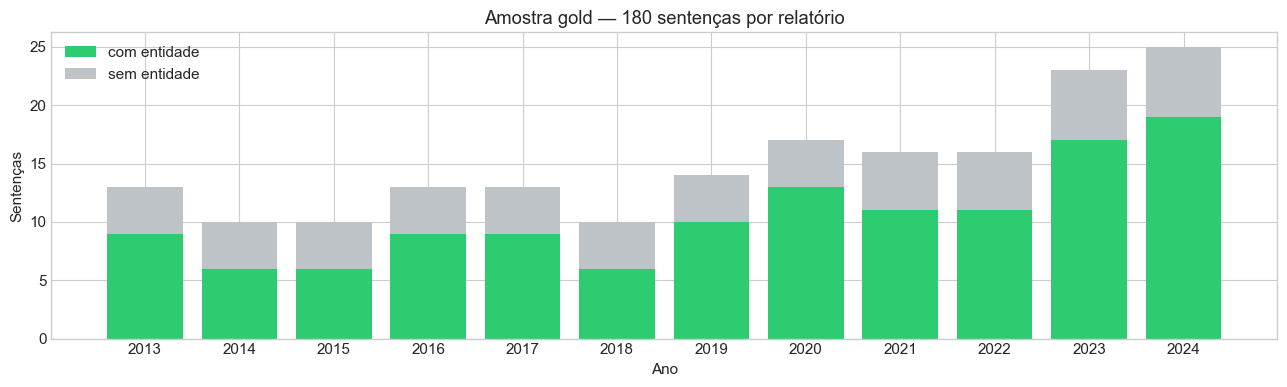

Ano         Total  c/Ent  s/Ent
------------------------------
  2013         13      9      4
  2014         10      6      4
  2015         10      6      4
  2016         13      9      4
  2017         13      9      4
  2018         10      6      4
  2019         14     10      4
  2020         17     13      4
  2021         16     11      5
  2022         16     11      5
  2023         23     17      6
  2024         25     19      6


In [7]:
# Distribuição por ano
per_year = Counter(r["relatorio"].replace("sireva_", "") for r in sample)
com_ent  = Counter(
    r["relatorio"].replace("sireva_", "")
    for r in sample
    if any(t != "O" for t in r["bio_tags"])
)

anos = sorted(per_year.keys())
totais  = [per_year[a] for a in anos]
c_ent   = [com_ent.get(a, 0) for a in anos]
s_ent   = [totais[i] - c_ent[i] for i in range(len(anos))]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(anos, c_ent, label="com entidade",  color="#2ecc71")
ax.bar(anos, s_ent, bottom=c_ent,          label="sem entidade", color="#bdc3c7")
ax.set_title(f"Amostra gold — {len(sample)} sentenças por relatório")
ax.set_xlabel("Ano")
ax.set_ylabel("Sentenças")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Ano':<10} {'Total':>6} {'c/Ent':>6} {'s/Ent':>6}")
print("-" * 30)
for a in anos:
    print(f"  {a:<8} {per_year[a]:>6} {com_ent.get(a,0):>6} {per_year[a]-com_ent.get(a,0):>6}")

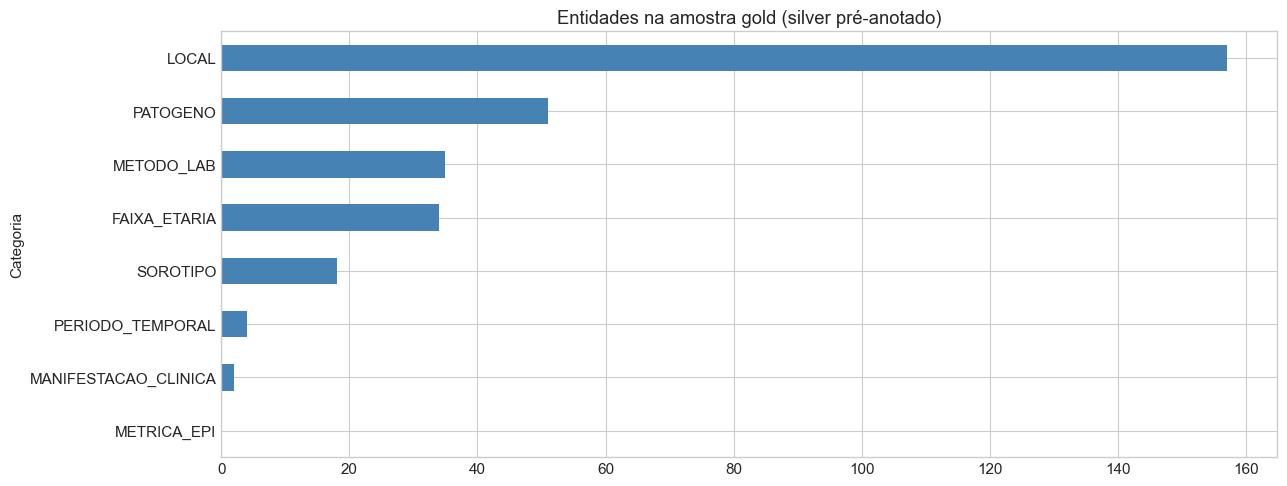

⚠ Categorias sem cobertura na amostra: ['METRICA_EPI']
  Considere aumentar N_TARGET ou ajustar PCT_COM_ENT.

Total de entidades pré-anotadas: 301


In [8]:
# Cobertura de entidades na amostra
ent_counts = Counter(
    tag[2:] for r in sample for tag in r["bio_tags"] if tag.startswith("B-")
)

ENTITY_NAMES = [
    "PATOGENO", "SOROTIPO", "FAIXA_ETARIA", "LOCAL",
    "PERIODO_TEMPORAL", "METODO_LAB", "METRICA_EPI", "MANIFESTACAO_CLINICA"
]

df_ent = pd.DataFrame(
    [(e, ent_counts.get(e, 0)) for e in ENTITY_NAMES],
    columns=["Categoria", "Ocorrências"]
).sort_values("Ocorrências", ascending=True)

ax = df_ent.plot.barh(x="Categoria", y="Ocorrências", legend=False, color="steelblue")
ax.set_title("Entidades na amostra gold (silver pré-anotado)")
plt.tight_layout()
plt.show()

missing = [e for e in ENTITY_NAMES if ent_counts.get(e, 0) == 0]
if missing:
    print(f"⚠ Categorias sem cobertura na amostra: {missing}")
    print("  Considere aumentar N_TARGET ou ajustar PCT_COM_ENT.")
else:
    print("✓ Todas as 8 categorias cobertas na amostra.")

print(f"\nTotal de entidades pré-anotadas: {sum(ent_counts.values())}")

In [9]:
# Exemplos de sentenças amostradas
print("Exemplos com entidades:\n")
examples = [r for r in sample if any(t != "O" for t in r["bio_tags"])][:5]
for r in examples:
    print(f"[{r['sentenca_id']}] {r['texto']}")
    for sp in r.get("spans", []):
        print(f"  → [{sp['tipo']}] {sp['texto']}")
    print()

Exemplos com entidades:

[sireva_2019_s0161] Centro de Lab Regional - Instituto Adolfo Lutz de Campinas
  → [LOCAL] Centro de Lab Regional - Instituto Adolfo Lutz de Campinas

[sireva_2015_s0009] Nesse  contexto,  o  IAL monitora as características fenotípicas e moleculares das cepas de Neisseria meningitidis , Haemophilus influenzae e Streptococcus pneumoniae isoladas de casos  de  doenças  invasiv.s  nos  estados  brasileiros  através  da  vigilância nacional de base laboratorial,
  → [PATOGENO] Neisseria meningitidis
  → [PATOGENO] Haemophilus influenzae
  → [PATOGENO] Streptococcus pneumoniae
  → [MANIFESTACAO_CLINICA] doenças invasivas
  → [LOCAL] estados brasileiros

[sireva_2020_s0088] Suscetibilidade a penicilina em ≥ 5 anos, por sorotipo e diagnóstico.
  → [FAIXA_ETARIA] ≥ 5 anos
  → [SOROTIPO] sorotipo
  → [METODO_LAB] diagnóstico

[sireva_2023_s0060] Os dados de suscetibilidade as drogas se referem às amostras diagnosticadas por cultura (n=219)
  → [METODO_LAB] cultura

[sir

## 7. Exportar

Gera dois arquivos:
- `data/gold/gold_sample.jsonl` — formato interno (tokens + bio_tags + spans)
- `data/gold/label_studio.json` — importar no Label Studio para revisão manual

In [10]:
# JSONL interno
out_jsonl = DATA_GOLD / "gold_sample.jsonl"
with out_jsonl.open("w", encoding="utf-8") as f:
    for r in sample:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"Salvo: {out_jsonl}  ({len(sample)} registros)")

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\gold\gold_sample.jsonl  (180 registros)


In [11]:
# Label Studio JSON
def spans_from_bio(tokens, bio_tags, texto):
    """Reconstrói spans com offsets de caractere a partir do BIO."""
    # Recalcula offsets dos tokens no texto
    offsets = []
    cursor = 0
    for tok in tokens:
        idx = texto.find(tok, cursor)
        if idx == -1:
            offsets.append(None)
        else:
            offsets.append((idx, idx + len(tok)))
            cursor = idx + len(tok)

    spans = []
    current = None
    for i, (tag, off) in enumerate(zip(bio_tags, offsets)):
        if off is None:
            if current:
                spans.append(current)
                current = None
            continue
        if tag.startswith("B-"):
            if current:
                spans.append(current)
            current = {"start": off[0], "end": off[1], "label": tag[2:]}
        elif tag.startswith("I-") and current:
            current["end"] = off[1]
        else:
            if current:
                spans.append(current)
            current = None
    if current:
        spans.append(current)

    for sp in spans:
        sp["text"] = texto[sp["start"]:sp["end"]]
    return spans


tasks = []
for idx, r in enumerate(sample):
    texto  = r["texto"]
    spans  = spans_from_bio(r["tokens"], r["bio_tags"], texto)

    task = {
        "id": idx + 1,
        "data": {
            "text":        texto,
            "sentenca_id": r["sentenca_id"],
            "relatorio":   r["relatorio"],
            "pagina":      r["pagina"],
        },
        "predictions": [{
            "model_version": "silver_gpt4o_mini",
            "score": 0.8,
            "result": [{
                "id":        f"t{idx}_{si}",
                "type":      "labels",
                "from_name": "label",
                "to_name":   "text",
                "value": {
                    "start":  sp["start"],
                    "end":    sp["end"],
                    "text":   sp["text"],
                    "labels": [sp["label"]],
                }
            } for si, sp in enumerate(spans)]
        }]
    }
    tasks.append(task)

out_ls = DATA_GOLD / "label_studio.json"
with out_ls.open("w", encoding="utf-8") as f:
    json.dump(tasks, f, ensure_ascii=False, indent=2)

print(f"Salvo: {out_ls}  ({len(tasks)} tarefas)")
print("\nPróximo passo: importar label_studio.json no Label Studio para revisão manual.")
print("\nConfiguração de labels para Label Studio:")
print("""
<View>
  <Labels name="label" toName="text">
    <Label value="PATOGENO"            background="#8e44ad"/>
    <Label value="SOROTIPO"            background="#9b59b6"/>
    <Label value="FAIXA_ETARIA"        background="#16a085"/>
    <Label value="LOCAL"               background="#2980b9"/>
    <Label value="PERIODO_TEMPORAL"    background="#7f8c8d"/>
    <Label value="METODO_LAB"          background="#27ae60"/>
    <Label value="METRICA_EPI"         background="#d35400"/>
    <Label value="MANIFESTACAO_CLINICA" background="#e74c3c"/>
  </Labels>
  <Text name="text" value="$text"/>
</View>
""")

Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\gold\label_studio.json  (180 tarefas)

Próximo passo: importar label_studio.json no Label Studio para revisão manual.

Configuração de labels para Label Studio:

<View>
  <Labels name="label" toName="text">
    <Label value="PATOGENO"            background="#8e44ad"/>
    <Label value="SOROTIPO"            background="#9b59b6"/>
    <Label value="FAIXA_ETARIA"        background="#16a085"/>
    <Label value="LOCAL"               background="#2980b9"/>
    <Label value="PERIODO_TEMPORAL"    background="#7f8c8d"/>
    <Label value="METODO_LAB"          background="#27ae60"/>
    <Label value="METRICA_EPI"         background="#d35400"/>
    <Label value="MANIFESTACAO_CLINICA" background="#e74c3c"/>
  </Labels>
  <Text name="text" value="$text"/>
</View>



## 8. Resumo

```
✅ data/gold/gold_sample.jsonl  — amostra com pré-anotação silver
✅ data/gold/label_studio.json  — pronto para importar no Label Studio

Próximos passos:
  1. pip install label-studio && label-studio
  2. Novo projeto → NER → usar configuração XML acima
  3. Importar label_studio.json
  4. Revisar/corrigir as ~180 sentenças (~2-3h de trabalho)
  5. Exportar CoNLL ou JSON → salvar em data/gold/
  6. Rodar evaluation.py (seqeval) para medir qualidade do silver
```